<a href="https://colab.research.google.com/github/jenny-yuu/Image-Processing-Final-Project/blob/main/VeriPromiseESG_0317.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 BERT 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 BERT 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| `promise_status` | 是否有承諾 | Yes / No |
| `verification_timeline` | 承諾時程 | already / within_2_years / between_2_and_5_years / longer_than_5_years / N/A |
| `evidence_status` | 是否有佐證 | Yes / No / N/A |
| `evidence_quality` | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### 評分方式
最終分數 = 加權平均 Macro F1：
- `promise_status` × 0.20
- `evidence_status` × 0.30  
- `evidence_quality` × 0.35
- `verification_timeline` × 0.15

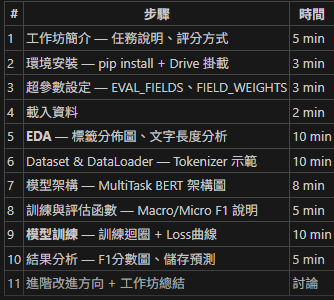



---



## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [25]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q
print("套件安裝完成！")

套件安裝完成！


In [26]:
# 從 GitHub 下載公開資料集（不需要 Google Drive）
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
print("資料下載完成！")

資料下載完成！


In [27]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 中文字型設定（Colab）
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("所有套件載入完成！")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

所有套件載入完成！
PyTorch 版本: 2.10.0+cu128
CUDA 可用: True




---



## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `bert-base-chinese`，這是 Google 發布的中文 BERT 模型
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 BERT fine-tuning 使用 2e-5

### 為什麼用 bert-base-chinese？
BERT（Bidirectional Encoder Representations from Transformers）是一個雙向 Transformer 模型。
中文版本在大量中文語料上預訓練，能夠理解中文文字的語意。

In [28]:
# ============================================================
# 超參數設定
# ============================================================
# 修改前
# MODEL_NAME = 'bert-base-chinese'
# MAX_LEN    = 256
# BATCH_SIZE = 8

# 修改後 (請直接覆蓋)
MODEL_NAME = 'hfl/chinese-roberta-wwm-ext-large' # 強大 24 層版本
MAX_LEN    = 512                                  # 防止長證據被截斷
BATCH_SIZE = 4                                    # Large 模型較吃顯存，建議改小
EPOCHS     = 15                                    # 訓練完整資料集的次數
LR         = 2e-5                                 # 學習率

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"],
}

# 各欄位的評分權重
FIELD_WEIGHTS = {
    "promise_status": 0.20,
    "evidence_status": 0.30,
    "evidence_quality": 0.35,
    "verification_timeline": 0.15,
}

# 建立標籤 ↔ ID 的對應表
label2id = {field: {lab: i for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: lab for i, lab in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print("超參數設定完成！")
print("\n標籤對應表：")
for field, mapping in label2id.items():
    print(f"  {field}: {mapping}")

超參數設定完成！

標籤對應表：
  promise_status: {'Yes': 0, 'No': 1}
  verification_timeline: {'already': 0, 'within_2_years': 1, 'between_2_and_5_years': 2, 'longer_than_5_years': 3, 'N/A': 4}
  evidence_status: {'Yes': 0, 'No': 1, 'N/A': 2}
  evidence_quality: {'Clear': 0, 'Not Clear': 1, 'Misleading': 2, 'N/A': 3}




---



## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [29]:
from sklearn.model_selection import train_test_split

# 載入下載好的資料
with open("vpesg4k_train_1000.json", "r", encoding="utf-8") as f:
    all_data = json.load(f)

# 原本：有切分驗證集
# train_data, val_data = train_test_split(all_data, test_size=0.2, random_state=42)

# 修改後：全量訓練 (不留驗證集)
train_data = all_data
val_data   = all_data  # 驗證集也設為同一份，雖然此時驗證分數會虛高(Overfitting)，但能確保模型看過所有答案


print(f"資料載入成功！共 {len(all_data)} 筆")
print(f"   訓練集大小: {len(train_data)} 筆")
print(f"   驗證集大小: {len(val_data)} 筆")

資料載入成功！共 1000 筆
   訓練集大小: 1000 筆
   驗證集大小: 1000 筆


In [30]:
# --- Level 2: 過採樣 (Oversampling) ---
no_promise_samples = [d for d in train_data if d['promise_status'] == 'No']
# 將 "No" 的樣本複製 3 倍，幫助模型學習弱點
train_data.extend(no_promise_samples * 3)
print(f"過採樣後訓練集數量: {len(train_data)}")

過採樣後訓練集數量: 1558




---



## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [31]:
# 觀察單筆資料結構
sample = train_data[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10001
  data: 聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性...
  esg_type: S
  promise_status: Yes
  promise_string: 為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性員工則可於其配偶懷孕期間陪同產檢或生（流）產日及前後 15 日間請假陪伴，兩者合計共有 10 天陪產（檢）假可運用，陪產（檢）假期間工資照常給付。
  verification_timeline: already
  evidence_status: No
  evidence_string: 
  evidence_quality: N/A
  company: mediatek
  ticker: 2454
  page_number: 48
  pdf_url: https://hsxn1sjvkgtdpixe.public.blob.vercel-storage.com/mediatek_2454_page_48.pdf
  company_source: https://corp.mediatek.tw/about/sustainability


In [32]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                        int64
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                    int64
page_number               int64
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


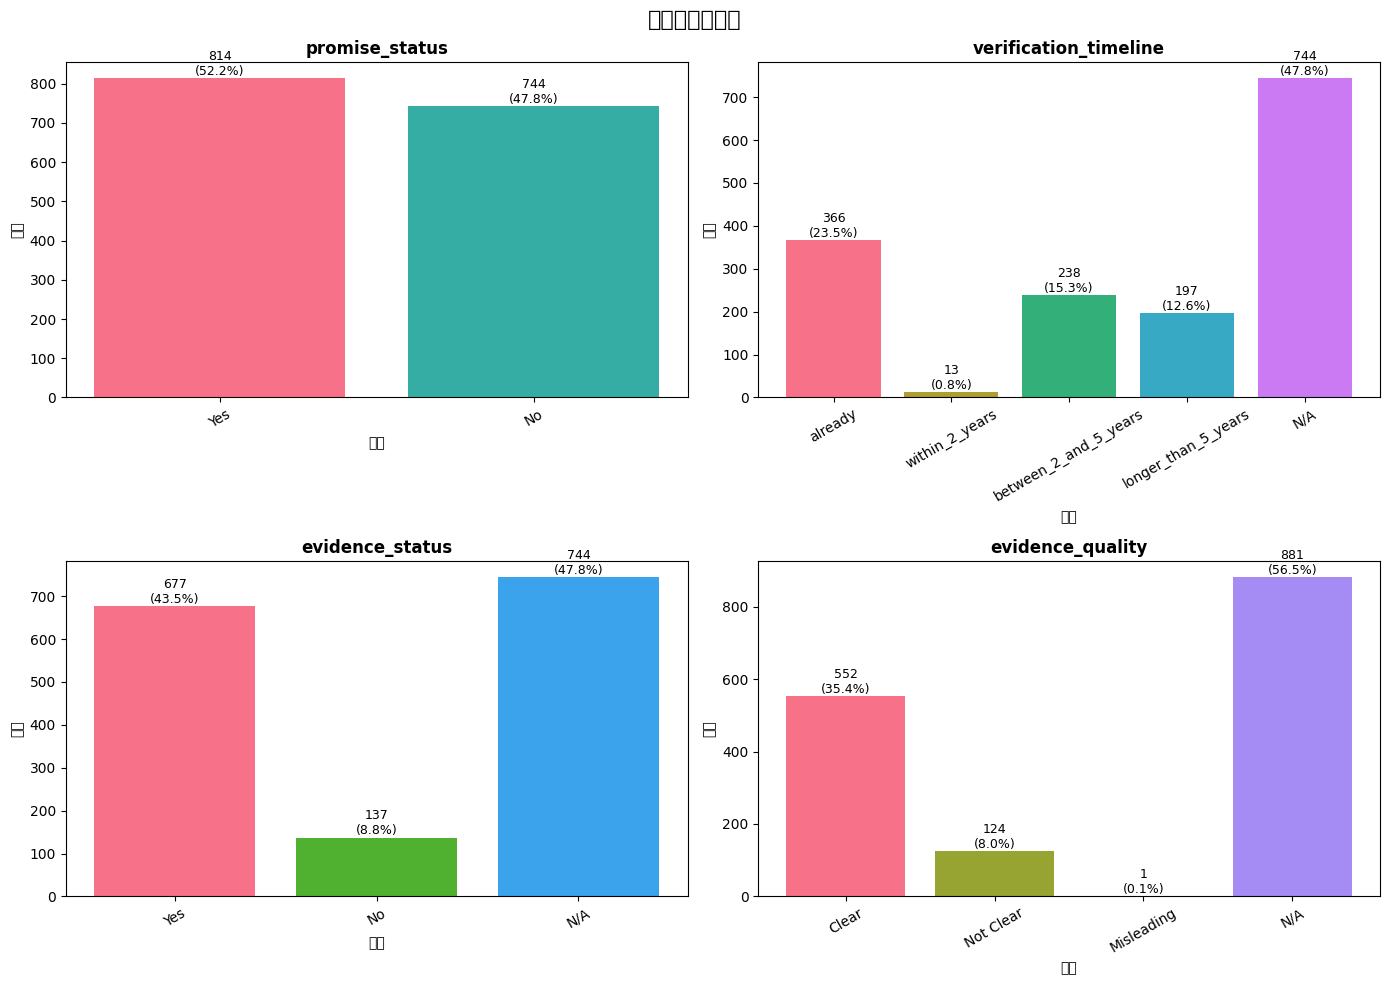

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [33]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("訓練集標籤分佈", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("標籤")
    ax.set_ylabel("數量")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

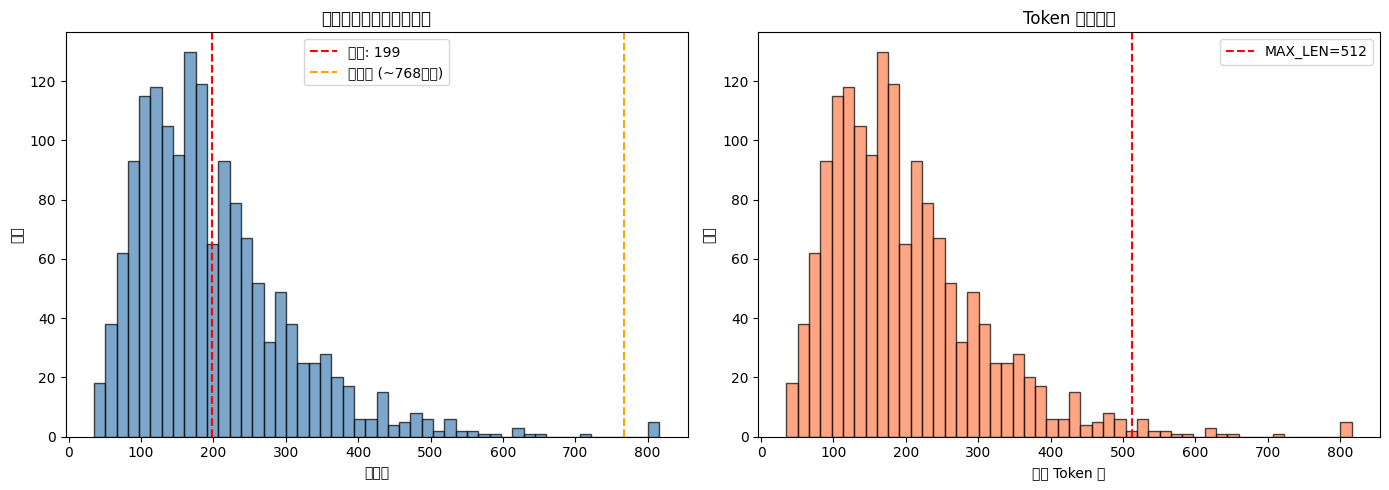

超過 MAX_LEN=512 的樣本數: 23 (1.5%)
   這些文字將被截斷，可能損失尾端資訊


In [34]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"平均: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"截斷點 (~{MAX_LEN * 1.5:.0f}字元)")
axes[0].set_title("文字長度分佈（字元數）")
axes[0].set_xlabel("字元數")
axes[0].set_ylabel("數量")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Token 長度估算")
axes[1].set_xlabel("估算 Token 數")
axes[1].set_ylabel("數量")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")



---



## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [35]:
class ESGDataset(Dataset):
    """
    ESG 資料集類別

    Args:
        data: JSON 資料列表，每筆包含 'data' 文字和標籤欄位
        tokenizer: BERT tokenizer
        label2id: 標籤到 ID 的映射字典
    """
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # 將文字 Tokenize
        # - padding="max_length": 補齊到 MAX_LEN
        # - truncation=True: 超過 MAX_LEN 就截斷
        # - return_tensors="pt": 返回 PyTorch tensor
        encoding = self.tokenizer(
            item["data"],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        # 將標籤文字轉換成數字 ID
        labels = {}
        for field, mapping in self.label2id.items():
            labels[field] = mapping[item[field]]

        return {
            "input_ids": encoding["input_ids"].squeeze(0),       # Token ID 序列
            "attention_mask": encoding["attention_mask"].squeeze(0),  # 1=真實token, 0=padding
            "labels": labels,
        }


def collate_fn(batch):
    """
    將一個 batch 的樣本整合成 tensor
    因為 labels 是 dict，預設的 collate 無法處理，需自訂
    """
    input_ids = torch.stack([b["input_ids"] for b in batch])
    attention_mask = torch.stack([b["attention_mask"] for b in batch])
    labels = {
        field: torch.tensor([b["labels"][field] for b in batch])
        for field in EVAL_FIELDS
    }
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


print("Dataset 類別定義完成！")

Dataset 類別定義完成！


In [36]:
# 示範 Tokenizer 的效果
print("Tokenizer 示範")
print("=" * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f"載入 {MODEL_NAME} tokenizer")

sample_text = train_data[0]["data"][:50]
print(f"\n原始文字：{sample_text}")

tokens = tokenizer.tokenize(sample_text)
print(f"\nTokenize 後：{tokens}")

encoding = tokenizer(sample_text, max_length=20, padding="max_length", truncation=True)
print(f"\nInput IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範
載入 hfl/chinese-roberta-wwm-ext-large tokenizer

原始文字：聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其

Tokenize 後：['聯', '發', '科', '技', '除', '在', '「', '工', '作', '規', '則', '」', '中', '依', '照', '勞', '基', '法', '明', '確', '規', '定', '「', '員', '工', '在', '產', '假', '期', '間', '公', '司', '不', '得', '終', '止', '勞', '動', '契', '約', '」', '外', '，', '為', '支', '持', '同', '仁', '與', '其']

Input IDs (前20個)：[101, 5474, 4634, 4906, 2825, 7370, 1762, 519, 2339, 868, 6211, 1179, 520, 704, 898, 4212, 1246, 1825, 3791, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [37]:
# 建立 Dataset 實例
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")

DataLoader 建立完成！
   訓練集 Batch 數: 390
   驗證集 Batch 數: 390

Batch 結構：
   input_ids shape: torch.Size([4, 512])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([4, 512])
   labels['promise_status'] shape: torch.Size([4])
   labels['verification_timeline'] shape: torch.Size([4])
   labels['evidence_status'] shape: torch.Size([4])
   labels['evidence_quality'] shape: torch.Size([4])




---



## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 BERT backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[BERT Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
BERT 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [38]:
class OptimizedESGModel(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super(OptimizedESGModel, self).__init__()
        self.bert = BertModel.from_pretrained(model_name)

        # 動態取得隱藏層大小 (768 or 1024)
        hidden_size = self.bert.config.hidden_size

        self.promise_head = nn.Linear(hidden_size, 2)
        self.timeline_head = nn.Linear(hidden_size, 5)
        self.evidence_head = nn.Linear(hidden_size + 2, 3)
        self.quality_head = nn.Linear(hidden_size + 3, 4)

        self.dropout = nn.Dropout(0.1)


    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)

        promise_logits = self.promise_head(pooled_output)
        timeline_logits = self.timeline_head(pooled_output)

        evidence_input = torch.cat([pooled_output, promise_logits], dim=1)
        evidence_logits = self.evidence_head(evidence_input)

        quality_input = torch.cat([pooled_output, evidence_logits], dim=1)
        quality_logits = self.quality_head(quality_input)

        return {
            'promise_status': promise_logits,
            'verification_timeline': timeline_logits,
            'evidence_status': evidence_logits,
            'evidence_quality': quality_logits
        }




---



## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [39]:
def get_weighted_criterion():
    # 對少數類別加重權重，強迫模型不再「偏食」
    quality_weights = torch.tensor([1.0, 5.0, 10.0, 2.0]).to(device) # 特別加強 Not Clear 和 Misleading
    status_weights = torch.tensor([1.0, 8.0, 2.0]).to(device)
    timeline_weights = torch.tensor([1.0, 10.0, 2.0, 2.0, 2.0]).to(device)

    return {
        'promise_status': nn.CrossEntropyLoss(),
        'verification_timeline': nn.CrossEntropyLoss(weight=timeline_weights),
        'evidence_status': nn.CrossEntropyLoss(weight=status_weights),
        'evidence_quality': nn.CrossEntropyLoss(weight=quality_weights)
    }


def compute_loss(logits, targets, criteria):
    total_loss = 0
    for field in targets.keys():
        total_loss += criteria[field](logits[field], targets[field])

    # --- Level 2: 邏輯懲罰 (Logic Penalty) ---
    pred_promise = torch.argmax(logits['promise_status'], dim=1)
    pred_evidence = torch.argmax(logits['evidence_status'], dim=1)

    # 邏輯：Promise="No" (1) 且 Evidence 已選 "Yes" (0) 或 "No" (1) [非 N/A]
    # 這種自相矛盾的情況，給予 20% 的額外處罰
    penalty_mask = (pred_promise == 1) & (pred_evidence != 2)
    if penalty_mask.any():
        total_loss += 0.2 * total_loss

    return total_loss


def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criteria = get_weighted_criterion()
    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids, attention_mask)
        targets = {field: batch["labels"][field].to(device) for field in EVAL_FIELDS}
        loss = compute_loss(logits, targets, criteria)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if (step + 1) % 50 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Loss: {loss.item():.4f}")
    return total_loss / len(dataloader)

def predict(model, dataloader, device, id2label):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            # 轉換為標籤名稱
            batch_preds = {
                field: [id2label[field][idx] for idx in torch.argmax(logits[field], dim=1).cpu().numpy()]
                for field in EVAL_FIELDS
            }
            # 重新組合成物件列表
            for i in range(len(input_ids)):
                item = {field: batch_preds[field][i] for field in EVAL_FIELDS}
                all_preds.append(item)
    return all_preds

In [40]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標




---



## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OptimizedESGModel(MODEL_NAME).to(device)

# 設定優化器與學習率排程器
# 調低學習率讓 Large 模型更穩定，並增加預熱區比例
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5) # 原本是 2e-5

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.15 * total_steps) # 從 0.1 改為 0.15，提供更多預熱

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)


print(f"訓練設定：")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps} (前 10%)")
print(f"   Learning rate: {LR}")
print(f"   Optimizer: AdamW")

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext-large/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_c

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext-large
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


訓練設定：
   Total steps: 5850
   Warmup steps: 877 (前 10%)
   Learning rate: 2e-05
   Optimizer: AdamW


### 設置 Hugging Face Token (選用，但建議)
雖然先前的錯誤可能與討論區被禁用有關，但「未經身份驗證的請求」警告提示您應該提供 Hugging Face Token。這可以幫助您避免其他潛在的下載或模型存取問題，並獲得更高的請求速率。

**步驟：**
1. 前往 [Hugging Face](https://huggingface.co/settings/tokens) 網站並登入。
2. 創建一個新的 `Access Token`，選擇 `Read` 角色即可。
3. 在 Colab 的左側面板中點擊 `🔑` (Secrets / 機密金鑰) 圖標。
4. 新增一個機密金鑰，名稱為 `HF_TOKEN`，並將您剛才複製的 Token 貼入。
5. 勾選 `筆記本存取權`，讓這個筆記本可以使用該 Token。

In [42]:
# ============================================================
# 主訓練迴圈
# ============================================================
MODEL_SAVE_PATH = "best_model.pt"

best_score = 0.0
history = {"loss": [], "weighted_score": []}

print("開始訓練！")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # 訓練
    avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
    history["loss"].append(avg_loss)
    print(f"  平均 Loss: {avg_loss:.4f}")

    # 在驗證集上評估
    preds   = predict(model, val_loader, device, id2label)
    results = evaluate_hybrid(val_data, preds)

    current_score = results["final_weighted_score"]
    history["weighted_score"].append(current_score)

    print(f"\n  加權分數: {current_score:.5f}")
    for field in EVAL_FIELDS:
        r = results[field]
        print(f"     {field}: Macro F1={r['macro_f1']:.4f} (權重={r['weight']})")

    # 儲存最佳模型
    if current_score > best_score:
        best_score = current_score
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n 最佳模型已儲存！分數: {best_score:.5f}")

print(f"\n{'=' * 60}")
print(f"訓練完成！最佳加權分數: {best_score:.5f}")

開始訓練！

Epoch 1/15
----------------------------------------
  Step 50/390, Loss: 5.6389
  Step 100/390, Loss: 5.9833
  Step 150/390, Loss: 4.2804
  Step 200/390, Loss: 5.0668
  Step 250/390, Loss: 3.1874
  Step 300/390, Loss: 3.6223
  Step 350/390, Loss: 2.1625
  平均 Loss: 4.2194

  加權分數: 0.52467
     promise_status: Macro F1=0.8703 (權重=0.2)
     verification_timeline: Macro F1=0.3463 (權重=0.15)
     evidence_status: Macro F1=0.5517 (權重=0.3)
     evidence_quality: Macro F1=0.3805 (權重=0.35)

 最佳模型已儲存！分數: 0.52467

Epoch 2/15
----------------------------------------
  Step 50/390, Loss: 3.2845
  Step 100/390, Loss: 2.8829
  Step 150/390, Loss: 2.7689
  Step 200/390, Loss: 4.1212
  Step 250/390, Loss: 4.2502
  Step 300/390, Loss: 3.5627
  Step 350/390, Loss: 2.3779
  平均 Loss: 2.3350

  加權分數: 0.71497
     promise_status: Macro F1=0.9794 (權重=0.2)
     verification_timeline: Macro F1=0.5367 (權重=0.15)
     evidence_status: Macro F1=0.8178 (權重=0.3)
     evidence_quality: Macro F1=0.5521 (權重=0.35)


KeyboardInterrupt: 

In [43]:
# 設置 Hugging Face Token
# 載入 Colab Userdata，用於獲取您的機密金鑰
from google.colab import userdata
import os

# 從 Colab 機密金鑰中獲取 HF_TOKEN
# 請確保您已經在 Colab Secrets 中設定了 HF_TOKEN
try:
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        os.environ["HF_TOKEN"] = hf_token
        print("Hugging Face Token 已載入環境變數！")
    else:
        print("警告：HF_TOKEN 存在但為空值。請檢查 Colab Secrets 設定。")
except KeyError:
    print("警告：未找到 Hugging Face Token。若遇到下載問題，請依照上述步驟設定。")

# 重新載入模型以應用新的環境變數
# 這可能需要重新執行相關的 tokenizer 和 model from_pretrained() 程式碼
# 為了方便，我們重新運行整個模型定義和載入的區塊

# 這邊複製了原本載入 tokenizer 和 model 的程式碼，確保 Token 生效
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = OptimizedESGModel(MODEL_NAME).to(device)

print("Tokenizer 和模型已重新初始化！")

Hugging Face Token 已載入環境變數！


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext-large/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_c

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext-large
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer 和模型已重新初始化！


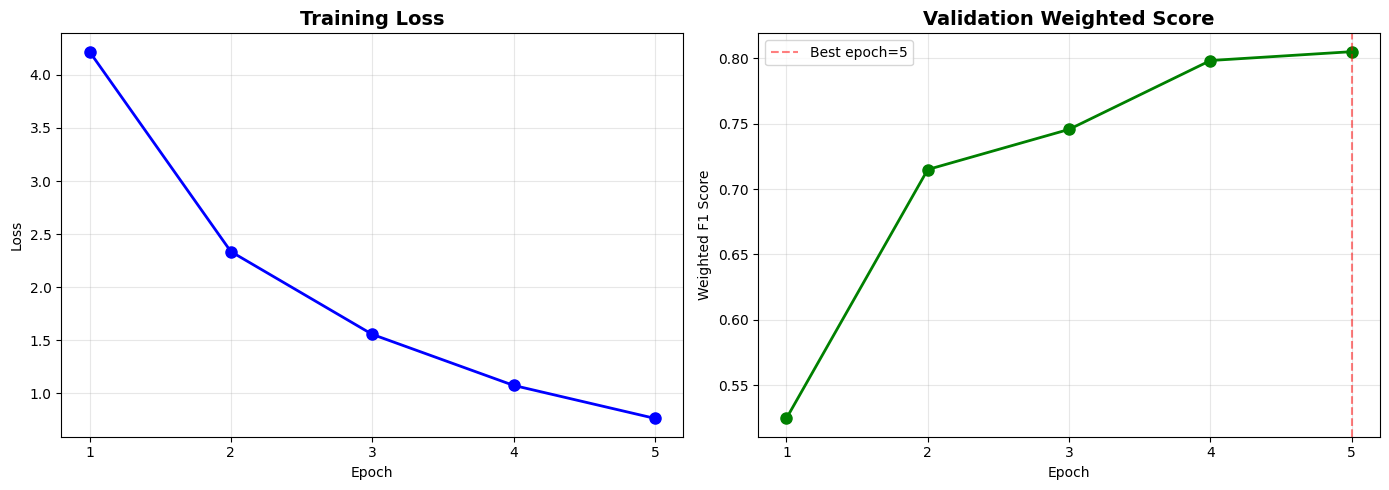

In [47]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 修正 epochs_range，使其與實際訓練的 epoch 數量一致
actual_epochs_completed = len(history["loss"])
epochs_range = range(1, actual_epochs_completed + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
# 確保 x 軸刻度只顯示實際完成的 epoch 數
axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
# 確保 x 軸刻度只顯示實際完成的 epoch 數
axes[1].set_xticks(epochs_range)

# 標記最佳點
# 只有當 history["weighted_score"] 非空時才計算最佳點
if history["weighted_score"]:
    best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
    axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()



---



## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [48]:
# 載入最佳模型
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f"已載入最佳模型")

# 最終預測
final_preds = predict(model, val_loader, device, id2label)
final_results = evaluate_hybrid(val_data, final_preds)

print(f"\n{'=' * 60}")
print(f"最終評估結果")
print(f"{'=' * 60}")

for field in EVAL_FIELDS:
    r = final_results[field]
    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")

print(f"\n{'=' * 60}")
print(f"最終加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")

已載入最佳模型

最終評估結果

--- promise_status (權重: 0.2) ---
              precision    recall  f1-score   support

         Yes       1.00      0.99      1.00       814
          No       0.99      1.00      1.00       744

    accuracy                           1.00      1558
   macro avg       1.00      1.00      1.00      1558
weighted avg       1.00      1.00      1.00      1558

  Macro F1: 0.9968
  Micro F1: 0.9968

--- verification_timeline (權重: 0.15) ---
                       precision    recall  f1-score   support

              already       1.00      0.69      0.82       366
       within_2_years       0.00      0.00      0.00        13
between_2_and_5_years       0.70      0.94      0.80       238
  longer_than_5_years       0.77      0.92      0.84       197
                  N/A       0.99      1.00      1.00       744

             accuracy                           0.90      1558
            macro avg       0.69      0.71      0.69      1558
         weighted avg       0.91     

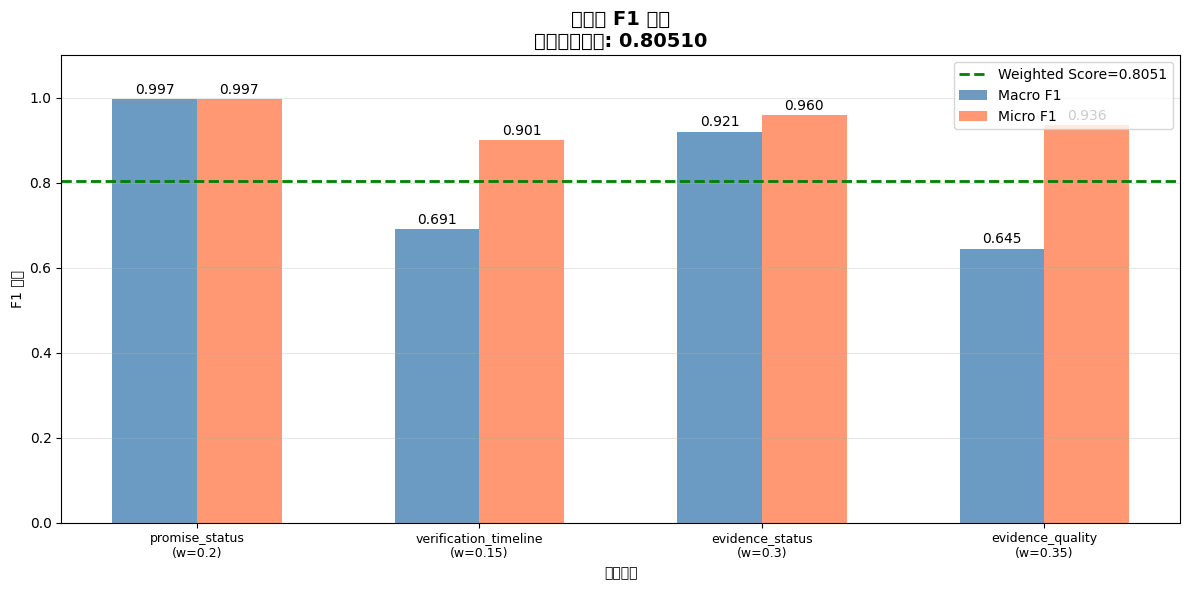

In [49]:
# 視覺化各欄位的 F1 分數
fields = list(EVAL_FIELDS.keys())
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
micro_f1s = [final_results[f]["micro_f1"] for f in fields]
weights   = [FIELD_WEIGHTS[f] for f in fields]

x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='coral',     alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("任務欄位")
ax.set_ylabel("F1 分數")
ax.set_title(f"各任務 F1 分數\n最終加權分數: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
           linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# 儲存預測結果
OUTPUT_PATH = "prediction.json"

output_data = []
for orig, pred in zip(val_data, final_preds):
    item = dict(orig)   # 複製原始資料
    item.update(pred)   # 覆蓋預測欄位
    output_data.append(item)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 預測結果已儲存至: {OUTPUT_PATH}")
print(f"   共 {len(output_data)} 筆")

# 顯示前3筆預測結果
print("\n📋 前3筆預測結果：")
for i, item in enumerate(output_data[:3]):
    print(f"\n--- 第{i+1}筆 (ID: {item.get('id', 'N/A')}) ---")
    for field in EVAL_FIELDS:
        print(f"  {field}: {item[field]}")

✅ 預測結果已儲存至: prediction.json
   共 1558 筆

📋 前3筆預測結果：

--- 第1筆 (ID: 10001) ---
  promise_status: Yes
  verification_timeline: already
  evidence_status: N/A
  evidence_quality: N/A

--- 第2筆 (ID: 10002) ---
  promise_status: Yes
  verification_timeline: between_2_and_5_years
  evidence_status: Yes
  evidence_quality: Not Clear

--- 第3筆 (ID: 10003) ---
  promise_status: Yes
  verification_timeline: between_2_and_5_years
  evidence_status: Yes
  evidence_quality: Not Clear


In [51]:
import pandas as pd
df_sub = pd.DataFrame(preds)
df_sub = df_sub[list(EVAL_FIELDS.keys())]
df_sub.to_csv("submission.csv", index=False, encoding="utf-8")
print("✅ 提交檔案已儲存: submission.csv")

✅ 提交檔案已儲存: submission.csv




---



## Step 10: 進階改進方向

恭喜你完成了基礎版本！以下是幾個可以進一步提升分數的方向：

### 1. 模型升級
```python
# 可以嘗試更大的模型
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"  # 中文 RoBERTa Large
MODEL_NAME = "bert-large-chinese"                   # BERT Large
```

### 2. 加入 Dropout 防止過擬合
```python
self.dropout = nn.Dropout(0.1)
pooled = self.dropout(outputs.pooler_output)
```

### 3. 損失加權（針對類別不均衡）
```python
# 給少數類別更高的損失權重
criterion = nn.CrossEntropyLoss(weight=class_weights)
```

### 4. 資料增強
- 同義詞替換
- 回譯（中→英→中）
- 隨機遮罩

### 5. 集成學習（Ensemble）
```python
# 訓練多個模型，取預測結果的多數票
from collections import Counter
ensemble_pred = Counter([model1_pred, model2_pred, model3_pred]).most_common(1)[0][0]
```

### 6. 調整超參數
- 增加 Epochs（10-15）
- 調整 Learning Rate（1e-5 ~ 5e-5）
- 增大 MAX_LEN（512）
- 嘗試不同 BATCH_SIZE

---
## 工作坊總結

今天我們學習了：
1. ESG 承諾驗證任務的定義
2. 使用 EDA 分析資料分佈
3. 實作 PyTorch Dataset & DataLoader
4. 設計 Multi-Task BERT 模型架構
5. 完整的訓練、評估、預測流程
6. 使用加權 Macro F1 評分

**祝大家在比賽中取得好成績！**